## Week 04 — Decision Boundary Lab

Goal: build a tiny classifier that learns to separate two groups of 2D points.

Each row has two input features:

- `x_position`
- `y_position`

The answer column is:

- `class_label`


In [52]:
from pathlib import Path

# Find the repo root so saved files go to the same place even if Jupyter
# starts from a different working directory.
def find_project_root(start: Path) -> Path:
   for candidate in [start, *start.parents]:
       # `pyproject.toml` is our marker for "this folder is the project root."
       if (candidate / "pyproject.toml").exists():
           return candidate
   raise FileNotFoundError("Could not find project root containing pyproject.toml.")
project_root = find_project_root(Path.cwd()).resolve()


### Project root

The notebook finds the project root by looking for `pyproject.toml`.

This keeps saved files going to the repo folders even if Jupyter starts from a different directory.


### Generated 2D dataset

`make_blobs` creates reproducible practice data.

We expect:

- 300 rows
- 3 columns
- two visible clusters
- class `0` mostly near `(-2, -2)`
- class `1` mostly near `(2, 2)`


In [53]:
import pandas as pd
from sklearn.datasets import make_blobs

RANDOM_STATE = 42
LEARNING_RATE = 0.01

data_path = project_root / "data" / "generated" / "week-04-2d-points.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)

# `make_blobs` labels points by center order:
# first center -> class 0, second center -> class 1.
X, y = make_blobs(
    n_samples=300,
    centers=[(2.0, 2.0), (-2.0, -2.0)],
    # Larger `cluster_std` means more spread/overlap; smaller means cleaner clusters.
    cluster_std=0.9,
    random_state=RANDOM_STATE,
)

points = pd.DataFrame(
    {
        "x_position": X[:, 0],
        "y_position": X[:, 1],
        "class_label": y,
    }
)

# Save without the pandas display index so the CSV only has the real columns.
points.to_csv(data_path, index=False)
print(points.shape)
points.head()


(300, 3)


,x_position,y_position,class_label
0,0.927827,2.590898,0
1,1.510056,2.099830,0
2,-1.891734,-1.537005,1
3,1.116642,2.415893,0
4,2.052388,0.971327,0


### Dataset check

The dataset shape is `(300, 3)`: 300 points and 3 stored columns.

The notebook display index (`0`, `1`, `2`, ...) is not a CSV column because we save with `index=False`.


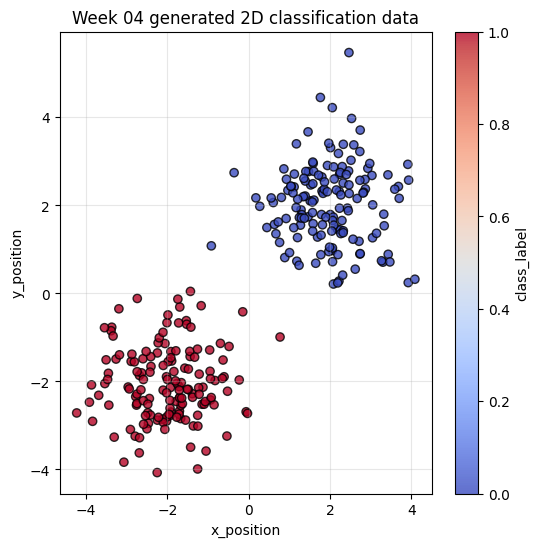

C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-04-classification\data_plot.png


In [54]:
import matplotlib.pyplot as plt

artifact_path = project_root / "artifacts" / "week-04-classification" / "data_plot.png"
artifact_path.parent.mkdir(parents=True, exist_ok=True)

figure, axis = plt.subplots(figsize=(6, 6))

scatter = axis.scatter(
   points["x_position"],
   points["y_position"],
   c=points["class_label"],
   cmap="coolwarm",
   edgecolors="black",
   alpha=0.8,
)

axis.set_title("Week 04 generated 2D classification data")
axis.set_xlabel("x_position")
axis.set_ylabel("y_position")
axis.grid(True, alpha=0.3)

figure.colorbar(scatter, ax=axis, label="class_label")
figure.savefig(artifact_path, dpi=150, bbox_inches="tight")

plt.show()

print(artifact_path)

### Data plot observation

The two classes are clearly separated.

This means a simple straight-line classifier should have a good chance of working.


In [55]:
import numpy as np
from numpy.typing import NDArray

from sklearn.model_selection import train_test_split

FloatArray = NDArray[np.float64]
IntArray = NDArray[np.int64]

# Features are the inputs the model sees.
features: FloatArray = points[["x_position", "y_position"]].to_numpy(dtype=np.float64)

# Labels are the correct answers used by the loss function.
labels: IntArray = points["class_label"].to_numpy(dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=RANDOM_STATE,
    # `stratify` keeps class balance similar in train and test sets.
    stratify=labels,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
# `bincount` shows how many examples of each integer class label we have.
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


X_train: (240, 2)
X_test: (60, 2)
y_train: (240,)
y_test: (60,)
Train class counts: [120 120]
Test class counts: [30 30]


### Train/test split

The data was split into:

- 240 training rows
- 60 test rows

`stratify=labels` kept the class balance:

- train: 120 class `0`, 120 class `1`
- test: 30 class `0`, 30 class `1`

`np.bincount` counts how many times each integer label appears.


In [56]:
import torch

# Inputs are floating-point tensors because model weights are floats.
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# BCE loss expects labels shaped like the model output: one value per row.
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("X_train_tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train_tensor:", y_train_tensor.shape, y_train_tensor.dtype)
print("X_test_tensor:", X_test_tensor.shape, X_test_tensor.dtype)
print("y_test_tensor:", y_test_tensor.shape, y_test_tensor.dtype)


X_train_tensor: torch.Size([240, 2]) torch.float32
y_train_tensor: torch.Size([240, 1]) torch.float32
X_test_tensor: torch.Size([60, 2]) torch.float32
y_test_tensor: torch.Size([60, 1]) torch.float32


### Tensor shapes

The model input has shape `(rows, 2)` because each point has two features.

The labels have shape `(rows, 1)` because each row has one binary answer.


In [57]:
from torch import nn

class BinaryLinearClassifier(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        # One linear layer creates one raw score from two input features.
        self.linear = nn.Linear(in_features=2, out_features=1)
    
    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        # Raw score/logit = weight_1 * x_position + weight_2 * y_position + bias.
        return self.linear(inputs)

torch.manual_seed(RANDOM_STATE)
model = BinaryLinearClassifier()

print(model)
print(f"Weight shape: {model.linear.weight.shape}")
print(f"Bias shape: {model.linear.bias.shape}")


BinaryLinearClassifier(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)
Weight shape: torch.Size([1, 2])
Bias shape: torch.Size([1])


### Linear classifier intuition

`in_features=2` means the model receives two input numbers:

- `x_position`
- `y_position`

The bias is not an input feature. It is an extra learned number.

The model learns:

```text
score = weight_1 * x_position + weight_2 * y_position + bias
```


 The output is a logit. Later we will turn it into:

 - probability near 0 → class 0
 - probability near 1 → class 1

### Loss function and optimizer

The model outputs logits: raw scores before probability.

For binary classification, we use `BCEWithLogitsLoss`.

This compares:

```text
model logits + true labels -> wrongness score
```

`BCEWithLogitsLoss` internally combines:

```text
sigmoid(logit) + binary cross entropy
```

The optimizer uses that loss to update the model's weights and bias.


In [58]:
# BCEWithLogitsLoss compares raw logits with true 0/1 labels.
# Internally: sigmoid(logit) + binary cross entropy.
loss_function = nn.BCEWithLogitsLoss()

# SGD updates weights and bias using gradients from loss.backward().
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

nb_rows = 5
with torch.no_grad():
    first_logits = model(X_train_tensor[:nb_rows])
    first_probabilities = torch.sigmoid(first_logits)


print("First logits:")
print(first_logits)

print("First probabilities:")
print(first_probabilities)

print("True labels:")
print(y_train_tensor[:nb_rows])


First logits:
tensor([[-2.3317],
        [ 2.7750],
        [-2.2630],
        [ 2.8984],
        [-1.1341]])
First probabilities:
tensor([[0.0885],
        [0.9413],
        [0.0942],
        [0.9478],
        [0.2434]])
True labels:
tensor([[1.],
        [0.],
        [1.],
        [0.],
        [1.]])


### Untrained baseline

Before training, the model already has random weights and a bias.

Those random numbers already create a decision boundary.

Measuring the untrained model tells us whether training actually improves anything.


In [59]:
with torch.no_grad():
       untrained_logits = model(X_train_tensor)
       untrained_probabilities = torch.sigmoid(untrained_logits)
       untrained_predictions = (untrained_probabilities >= 0.5).to(dtype=torch.float32)
       untrained_accuracy = (untrained_predictions == y_train_tensor).to(dtype=torch.float32).mean()

print("Initial weights:", model.linear.weight)
print("Initial bias:", model.linear.bias)
print("Untrained train accuracy:", untrained_accuracy.item())

Initial weights: Parameter containing:
tensor([[0.5406, 0.5869]], requires_grad=True)
Initial bias: Parameter containing:
tensor([-0.1657], requires_grad=True)
Untrained train accuracy: 0.004166666883975267


### Initial loss

Accuracy only counts right or wrong after a threshold.

Loss also measures confidence.

A high initial loss means the model is often wrong, unsure, or confidently wrong.


In [60]:
with torch.no_grad():
    initial_loss = loss_function(model(X_train_tensor), y_train_tensor)

print("Initial loss:", initial_loss.item())

Initial loss: 2.401505708694458


### Training loop

Training repeats the same learning cycle:

```text
predict -> measure wrongness -> compute gradients -> update weights
```

If learning is working, loss should usually go down over time.


In [62]:
epochs = 200
losses: list[float] = []

for epoch in range(epochs):
    model.train()
    
    logits = model(X_train_tensor)
    
    loss = loss_function(logits, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 40 == 0 or epoch == epochs -1:
        with torch.no_grad():
            # Convert logits -> probabilities -> hard class predictions.
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).to(dtype=torch.float32)
            accuracy = (predictions == y_train_tensor).to(dtype=torch.float32).mean()
        print(f"epoch={epoch:03d} loss={loss.item():.4f} accuracy={accuracy.item():.4f}")


epoch=000 loss=0.1078 accuracy=1.0000
epoch=040 loss=0.0907 accuracy=1.0000
epoch=080 loss=0.0788 accuracy=1.0000
epoch=120 loss=0.0700 accuracy=1.0000
epoch=160 loss=0.0632 accuracy=1.0000
epoch=199 loss=0.0579 accuracy=1.0000


### Training observation

The loss dropped during training, and accuracy rose.

This means the model adjusted its weights and bias so the decision boundary better separates the two classes.

Even after accuracy becomes high, loss can keep decreasing because the model is becoming more confident.


### Loss curve

A loss curve visualizes the training story.

A downward curve means the model is reducing its average BCE penalty over epochs.


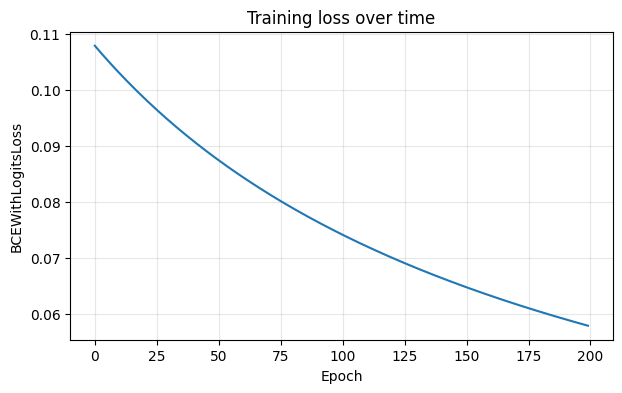

C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-04-classification\loss_curve.png


In [63]:
loss_curve_path = project_root / "artifacts" / "week-04-classification" / "loss_curve.png"

figure, axis = plt.subplots(figsize=(7, 4))

axis.plot(losses)
axis.set_title("Training loss over time")
axis.set_xlabel("Epoch")
axis.set_ylabel("BCEWithLogitsLoss")
axis.grid(True, alpha=0.3)

figure.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print(loss_curve_path)

### Test evaluation and confusion counts

The test set checks whether the learned boundary works on rows the model did not train on.

Confusion counts separate prediction results into:

- true positive: predicted `1`, actual `1`
- true negative: predicted `0`, actual `0`
- false positive: predicted `1`, actual `0`
- false negative: predicted `0`, actual `1`


In [64]:
import json

confusion_counts_path = project_root / "artifacts" / "week-04-classification" / "confusion_counts.json"

# Switch to evaluation mode before measuring on test data.
model.eval()

with torch.no_grad():
    # Test rows were not used for training, so they check generalization.
    test_logits = model(X_test_tensor)
    test_loss = loss_function(test_logits, y_test_tensor)
    
    test_probabilities = torch.sigmoid(test_logits)
    test_predictions = (test_probabilities >= 0.5).to(dtype=torch.float32)
    
    test_accuracy = (test_predictions == y_test_tensor).to(dtype=torch.float32).mean()


# Confusion counts separate the different kinds of right/wrong predictions.
true_positive = int(((test_predictions == 1) & (y_test_tensor == 1)).sum().item())
true_negative = int(((test_predictions == 0) & (y_test_tensor == 0)).sum().item())
false_positive = int(((test_predictions == 1) & (y_test_tensor == 0)).sum().item())
false_negative = int(((test_predictions == 0) & (y_test_tensor == 1)).sum().item())

confusion_counts = {
       "true_positive": true_positive,
       "true_negative": true_negative,
       "false_positive": false_positive,
       "false_negative": false_negative,
       "test_loss": test_loss.item(),
       "test_accuracy": test_accuracy.item(),
   }

confusion_counts_path.write_text(json.dumps(confusion_counts, indent=2), encoding="utf-8")

print(confusion_counts)
print(confusion_counts_path)


{'true_positive': 30, 'true_negative': 30, 'false_positive': 0, 'false_negative': 0, 'test_loss': 0.0621226541697979, 'test_accuracy': 1.0}
C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-04-classification\confusion_counts.json
